<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/data_visualization/matplotlib/practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ushbu sahifada matplotlib kutubxonasi amaliyot qilinadi . Datasetlar Sun'iy intellekt tomonidan yaratiladi.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 2023 yil davomida bitta onlayn do'konning kunlik sotuvlari ma'lumotlari -> AI yordamida yaratildi
np.random.seed(42)

dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Asosiy trend + mavsumiylik + shovqin
trend = np.linspace(1000, 1800, len(dates))
seasonality = 300 * np.sin(2 * np.pi * dates.dayofyear / 365)
noise = np.random.normal(0, 100, len(dates))

daily_sales = trend + seasonality + noise
daily_sales = np.clip(daily_sales, 200, None)  # manfiy bo'lmasin

df_sales = pd.DataFrame({
    'date': dates,
    'daily_revenue': daily_sales.round(2)
})
df_sales

,date,daily_revenue
0,2023-01-01,1054.84
1,2023-01-02,998.70
2,2023-01-03,1084.65
3,2023-01-04,1179.54
4,2023-01-05,1011.17
...,...,...
360,2023-12-27,1822.50
361,2023-12-28,1931.19
362,2023-12-29,1774.40
363,2023-12-30,1832.81


In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           365 non-null    datetime64[ns]
 1   daily_revenue  365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


In [4]:
df_sales.shape

(365, 2)

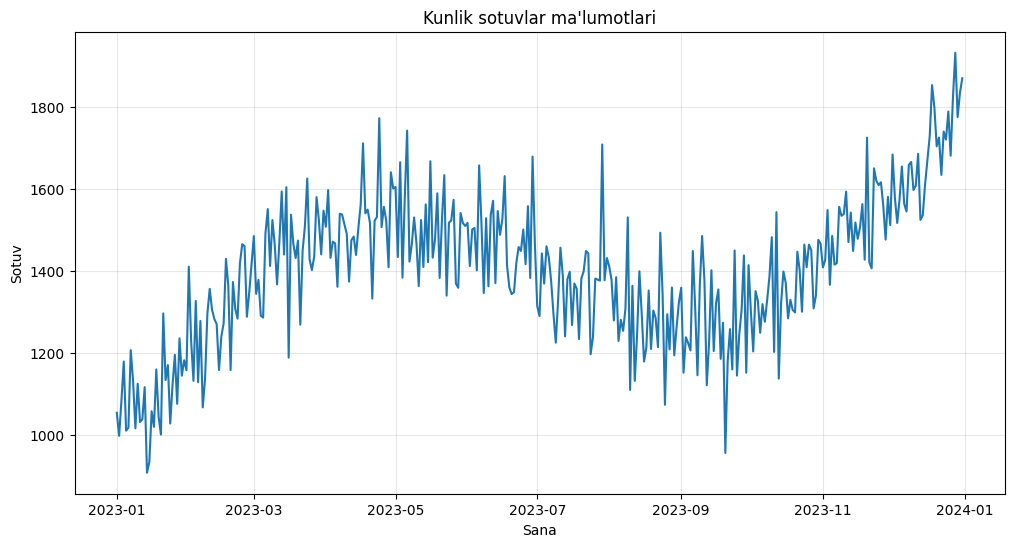

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(df_sales['date'], df_sales['daily_revenue'])

plt.title("Kunlik sotuvlar ma'lumotlari")
plt.xlabel("Sana")
plt.ylabel("Sotuv")

plt.grid(True, alpha=0.3)

plt.show()

- 2023-yil boshida sotuvlar 1000 ni tashkil qilgan bo'lsa , yil ohiri va 2024-yil boshiga kelib bu ko'rsatkich 1800 dan ham yuqorilagan . Bundan umumiy tendensiya o'sib borganini anglashimiz mumkin .
- Sotuvlar Bahor va Kuz oylarida yuqorilagan bo'lsa , Kuz va Qish oylarida sezirarli kamaygan .
- Kuz va Qishdagi sezirarli pasayishlarini oldini olish chora-tadbirlarini ko'rish kerak bo'ladi .

In [6]:
np.random.seed(7)

# Uchta mahsulot toifasining 2023 yildagi oylik sotuvlari (dona hisobida)
months = pd.date_range(start='2023-01-01', end='2023-12-01', freq='MS')

electronics = np.array([1200, 1350, 1100, 1450, 1600, 1750,
                         1900, 2100, 1800, 2300, 3200, 4100])

clothing = np.array([800, 750, 900, 1100, 1300, 1250,
                      1000, 950, 1150, 1400, 2200, 2800])

furniture = np.array([400, 420, 380, 500, 550, 600,
                       580, 620, 610, 700, 950, 1300])

df_monthly = pd.DataFrame({
    'month': months,
    'electronics': electronics,
    'clothing': clothing,
    'furniture': furniture
})
df_monthly.head()

,month,electronics,clothing,furniture
0,2023-01-01,1200,800,400
1,2023-02-01,1350,750,420
2,2023-03-01,1100,900,380
3,2023-04-01,1450,1100,500
4,2023-05-01,1600,1300,550


In [7]:
df_monthly.shape

(12, 4)

In [8]:
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   month        12 non-null     datetime64[ns]
 1   electronics  12 non-null     int64         
 2   clothing     12 non-null     int64         
 3   furniture    12 non-null     int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 516.0 bytes


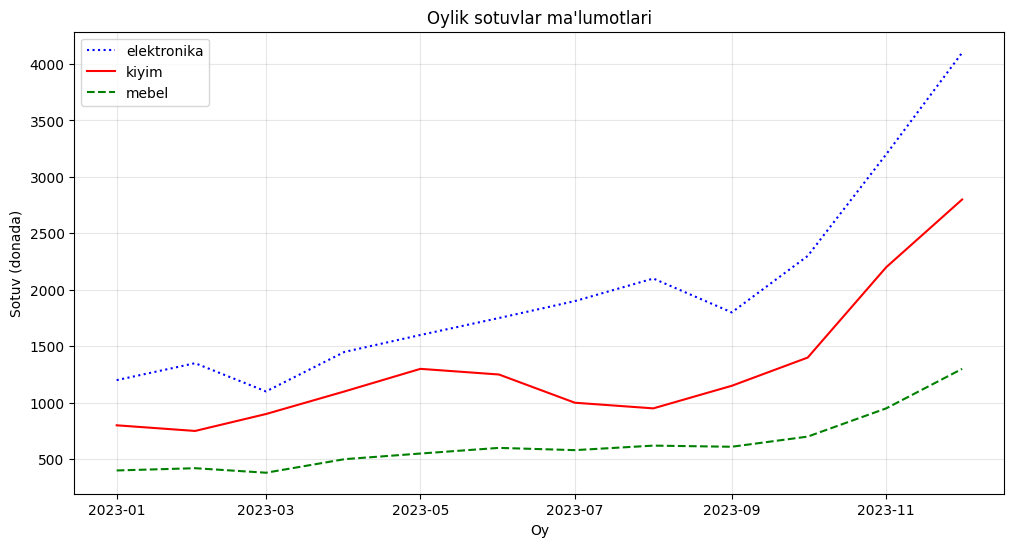

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(df_monthly['month'], df_monthly['electronics'], label='elektronika', color='blue', linestyle=':')
plt.plot(df_monthly['month'], df_monthly['clothing'], label='kiyim', color='red')
plt.plot(df_monthly['month'], df_monthly['furniture'], label='mebel', color='green', linestyle='--')

plt.title("Oylik sotuvlar ma'lumotlari")
plt.xlabel("Oy")
plt.ylabel("Sotuv (donada)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

- Elektronika yil davomida eng yuqori ko'rsatgichga ega bo'lgan , Mebellar esa doimiy past ko'rsatgichni qayd etgan .
- Barcha mahsulotlar bo'yicha Kuz oylarini ohiri va Qish oylarida yuqori o'sish kuzatilgan
- Elektronika va Kiyim-kechaklarda avgust va sentabr oylarida bir xil pasayishlar bo'lgan
- Keyingi yilda - elektronika va kiyimga katta e'tibor berish va yoz , kuz oylarida chegirmalar qilish tavsiya qilinadi .

In [10]:
np.random.seed(21)

# 200 ta uy-joyning maydoni va narxi

df_housing = pd.DataFrame({
    'area_sqm': np.random.normal(120, 40, 200).clip(30, 300).round(1),
    'price_usd': None  # vaqtinchalik, pastda hisoblanadi
})

df_housing['price_usd'] = (df_housing['area_sqm'] * 850 +
                             np.random.normal(0, 8000, 200)).clip(15000, None).round(0)

df_housing.head()

,area_sqm,price_usd
0,117.9,120773.0
1,115.6,92867.0
2,161.7,134587.0
3,69.7,47631.0
4,149.8,132097.0


In [11]:
df_housing.shape

(200, 2)

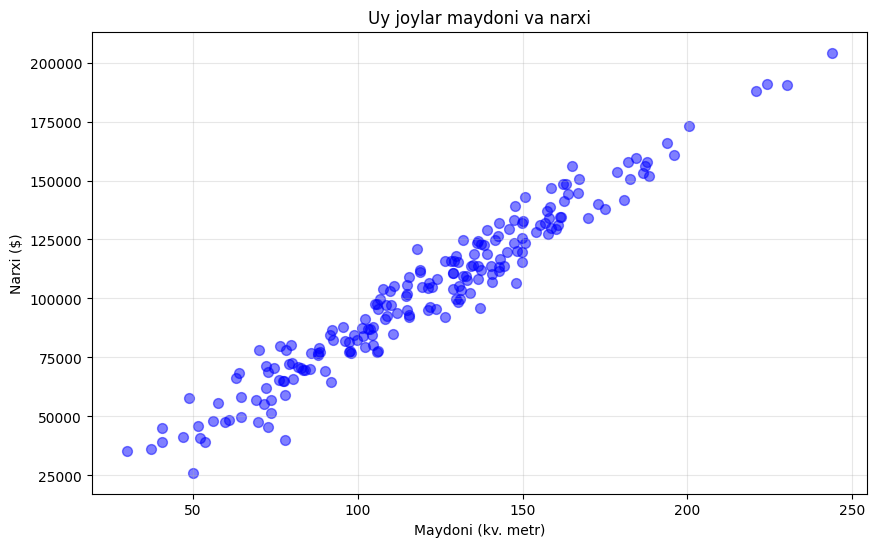

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df_housing['area_sqm'], df_housing['price_usd'], color='blue', alpha=0.5, s=50)

plt.title("Uy joylar maydoni va narxi")
plt.xlabel("Maydoni (kv. metr)")
plt.ylabel("Narxi ($)")

plt.grid(True, alpha=0.3)

plt.show()

- Ushbu grafikdan uy-joylarning maydoni va narxi o'rtasidagi bog'liqlik qanchalik yaxshi yoki yomon ekanini ko'rishimiz mumkin
- Uy maydoni oshgani sari , uning narxi ham shunga mos ravishda oshib bormoqda . Bu ijobiy bog'liqlik borligini bildiradi
- Aksar uylar 80 kv metr va 170 kv metr hamda narxlari esa 65000 dan 150000 gacha bo'lgan oraliqda to'plangan
- Grafik bir necha anomal qiymatlarni ham ko'rsatmoqda . Hususan , 50 kv metr uy juda arzonligi va 200 kv metrdan ko'p hajmli uylar juda qimmatligi shubhali
- Demak , uy-joylarning narxini belgilashda ularning kv metrlariga bog'lash maqsadga muvofiq bo'ladi

In [13]:
np.random.seed(33)

# 250 ta xodim ma'lumotlari

df_employees = pd.DataFrame({
    'experience_years': np.random.uniform(0, 20, 250).round(1),
    'department': np.random.choice(['Sales', 'Engineering', 'Marketing'], 250, p=[0.4, 0.35, 0.25])
})

df_employees['annual_salary'] = (
    np.where(df_employees['department'] == 'Engineering', 45000,
    np.where(df_employees['department'] == 'Sales', 35000, 32000))
    + df_employees['experience_years'] * 2200
    + np.random.normal(0, 4000, 250)
).round(0)

df_employees.head()

,experience_years,department,annual_salary
0,5.0,Sales,47253.0
1,9.0,Engineering,72833.0
2,8.2,Marketing,53034.0
3,5.2,Sales,43986.0
4,17.4,Sales,65567.0


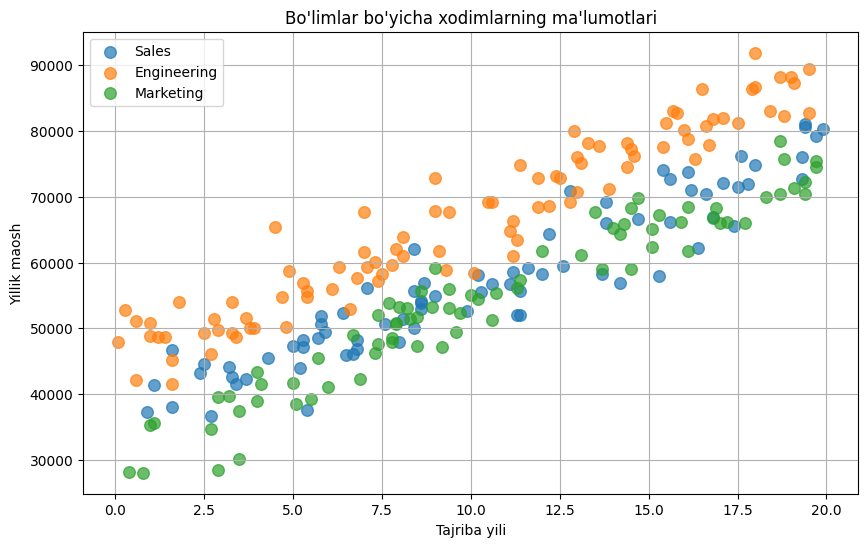

In [14]:
plt.figure(figsize=(10, 6))
departments = df_employees['department'].unique()
for dep in departments:
  dept_df = df_employees[df_employees['department'] == dep]
  plt.scatter(dept_df['experience_years'], dept_df['annual_salary'], label=dep, s=70, alpha=0.7)


plt.title("Bo'limlar bo'yicha xodimlarning ma'lumotlari")
plt.xlabel("Tajriba yili")
plt.ylabel("Yillik maosh")

plt.legend()
plt.grid()

plt.show()

- Grafik - xodimlarning tajriba yili va yillik maoshi o'rtasidagi bog'liqlikni uchta bo'lim bo'yicha (Sales, Engineering, Marketing) ko'rsatyapti  
- Har bir bo'limdagi xodimning tajribasi oshgani sari , uning yillik maoshi ham oshib boradi , bu ijobiy bog'liqlik degani
- Bir xil tajriba yiliga ega bo'lgan xodimlar orasida "Engineering" bo'limi vakillari doimiy ravishda eng yuqori maosh olishgan
- "Sales" va "Marketing" bo'limlari xodimlarining maoshlari bir-biriga juda yaqin guruhlangan, biroq Marketing asosan eng pastki chegarani egallagan
- Eng yuqori maosh 17-20 yillik tajribaga ega Engineering xodimi tomonidan olingan bo'lsa , eng kam maosh 0-5 yil tajribaga ega marketingchi olgan .

In [15]:
np.random.seed(14)

#do'konning 6 ta mahsulot toifasi bo'yicha jami sotilgan birliklar soni
df_product_sales = pd.DataFrame({
    'product_category': ['Electronics', 'Clothing', 'Furniture', 'Groceries', 'Toys', 'Books'],
    'total_units_sold': np.random.randint(500, 5000, 6)
})
df_product_sales

,product_category,total_units_sold
0,Electronics,3167
1,Clothing,1792
2,Furniture,2954
3,Groceries,4333
4,Toys,1732
5,Books,971


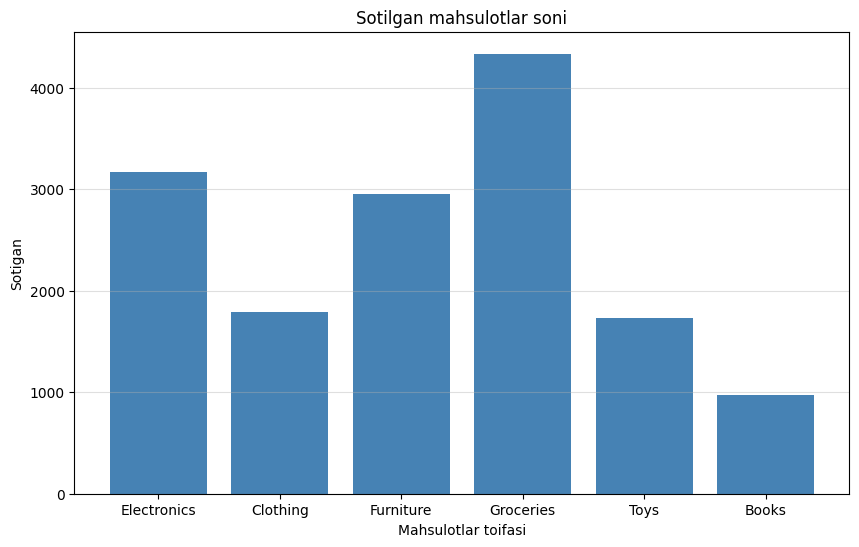

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(df_product_sales['product_category'], df_product_sales['total_units_sold'], color=['steelblue'])

plt.title("Sotilgan mahsulotlar soni")
plt.xlabel("Mahsulotlar toifasi")
plt.ylabel("Sotigan")
plt.grid(axis='y', alpha=0.4)

plt.show()

- Do'konning eng ko'p sotiladigan mahsuloti - oziq-ovqat mahsulotlari hisoblanadi . Grafikda aynan u eng ko'p sotilganini ko'rishimiz mumkin . Eng kam sotilgan mahsulot esa kitoblar bo'ladi
- Elektronika va mebellar sotuvlari ham yuqori ko'rsatgichga ega
- Kiyim-kechak va o'yinchoqlar bir birga juda yaqinligi ko'rinib turibdi
- Kitoblar sotuvini yaxshilash uchun , assortimentlarni qayta ko'rib chiqish yoki marketing orqali sotuvini yaxshilash tavsiya etiladi .

In [17]:
# kompaniyaning 4 ta mintaqada 2022 va 2023 yillardagi yillik daromadi
np.random.seed(50)

df_regional_sales = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West'],
    'revenue_2022': [420, 310, 275, 390],
    'revenue_2023': [460, 340, 250, 480]
})

df_regional_sales

,region,revenue_2022,revenue_2023
0,North,420,460
1,South,310,340
2,East,275,250
3,West,390,480


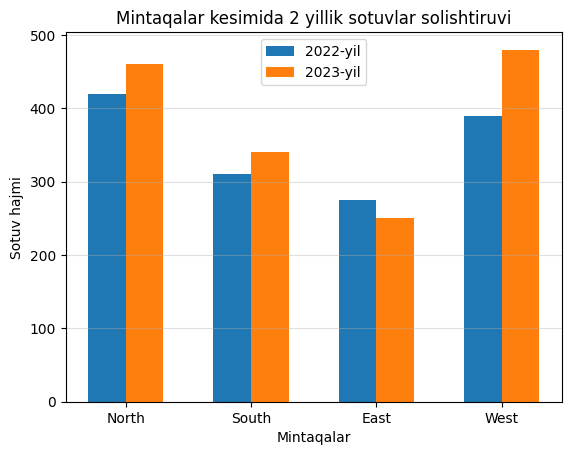

In [18]:
x = np.arange(len(df_regional_sales['region']))
width = 0.3
plt.bar(x - width/2, df_regional_sales['revenue_2022'], width, label='2022-yil', color='#1f77b4')
plt.bar(x + width/2, df_regional_sales['revenue_2023'], width, label='2023-yil', color='#ff7f0e')

plt.title("Mintaqalar kesimida 2 yillik sotuvlar solishtiruvi")
plt.xlabel("Mintaqalar")
plt.ylabel("Sotuv hajmi")
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.xticks(x, df_regional_sales['region'])

plt.show()

- Shimol va G'arb ikkala yilda ham yuqori foydaga erishgan . Ikkala mintaqaning natijalari deyarli bir xil
- Ikkala yilda ham eng past natija ko'rsatgan mintaqa - Sharq hisoblanadi . Janub esa Sharqdan biroz yuqoriroq natija ko'rsatgan bo'lsa lekin uning ham yillik foydalari qolganlaridagidek yaxshi emas .
- Grafikdan barcha mintaqalar 2022-yilga qaraganda 2023-yilda ko'proq daromad qilishgani ko'rinmoqda . Faqatgina Sharq bundan mustasno . U yerda 2022-yilga qaraganda 2023-yilda kamayish bo'lgan .
- Eng katta foyda 2023-yil G'arbda bo'lgan .

In [19]:
# onlayn kiyim-kechak do'konining 600 ta mijozi yoshi haqidagi ma'lumotlar
np.random.seed(8)

df_customer_ages = pd.DataFrame({
    'customer_age': np.random.normal(32, 9, 600).clip(18, 70).round(0).astype(int)
})

df_customer_ages.head()

,customer_age
0,33
1,42
2,18
3,20
4,18


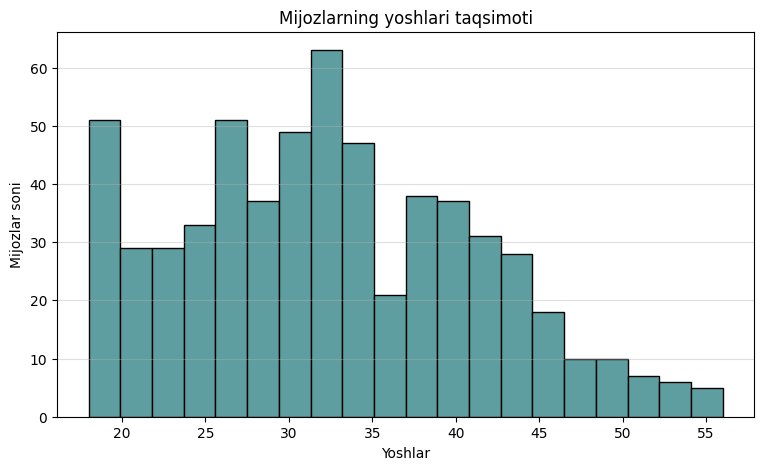

In [20]:
plt.figure(figsize=(9, 5))
plt.hist(df_customer_ages['customer_age'], bins=20, color='cadetblue', edgecolor='black')

plt.title("Mijozlarning yoshlari taqsimoti")
plt.xlabel("Yoshlar")
plt.ylabel("Mijozlar soni")
plt.grid(axis='y', alpha=0.4)

plt.show()

- Eng ko'p odamlarning yoshlari 29-34 yoshlar oralig'ida . Hamda bu taqsimotning eng yuqori nuqtasi bo'ladi .
- 18-20 yosh oralig'ida ham anchagina mijozlar borligi ko'rinadi . Yosh keksayib borgani sari mijozlar sezirarli kamaya borgan .
- 45 yoshdan oshgan mijozlar judayam kam
- Onlayn kiyim-kechak do'konining asosiy mijozlari 25-35 o'rta yoshdagilar hisoblanadi . Mahsulotlarning ko'p qismini aynan mana shu yoshdagilar uchun moslashtirish kerak . Katta yoshdagilarni jalb qilish uchun yangi strategiyalar o'ylash zarur .

In [21]:
# onlayn oziq-ovqat yetkazib berish xizmati bo'yicha yetkazib berish vaqti
# (yetkazib berish so'ralgandan mijozga yetib borgunga qadar, daqiqada)
np.random.seed(19)

df_delivery_times = pd.DataFrame({
    'delivery_minutes': np.concatenate([
        np.random.normal(28, 7, 630),
        np.random.normal(75, 15, 70)
    ]).clip(8, 120).round(1)
})

df_delivery_times.head()

,delivery_minutes
0,29.5
1,25.6
2,24.0
3,25.2
4,23.8


In [22]:
df_delivery_times.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   delivery_minutes  700 non-null    float64
dtypes: float64(1)
memory usage: 5.6 KB


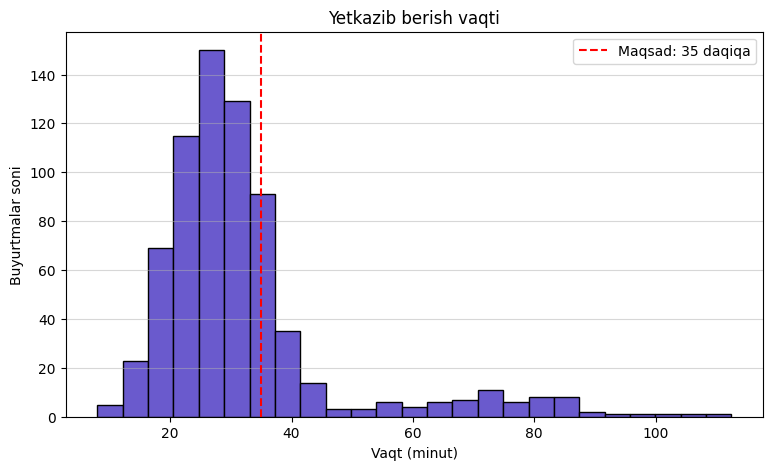

In [23]:
plt.figure(figsize=(9, 5))
plt.hist(df_delivery_times['delivery_minutes'], bins=25, color='slateblue', edgecolor='black')

plt.title("Yetkazib berish vaqti")
plt.xlabel("Vaqt (minut)")
plt.ylabel("Buyurtmalar soni")

plt.axvline(x=35, color='red', linestyle='--', label='Maqsad: 35 daqiqa')
plt.grid(axis='y', alpha=0.5)
plt.legend()

plt.show()

- Oziq-ovqatlarning ko'p qismi 20-40 daqiqa orasida yetkizib berilgan . Eng ko'p yetkizib berilgan oziq-ovqat mahsuloti 140 tadan yuqori bo'lib , ular 25-30 minut ichida yetkizilgan .
- Shunday bo'lsada , 50 minutdan 90 minutgacha ham yetkizib berilgan buyurtmalar bor . Mana shu buyurtmalar grafikni o'ng tomonga og'dirgan .
- 100 minutdan ko'p vaqt davomida yetkizilgan buyurtmalar ham bor .
- Grafik , yetkizib berish xizmati o'rtacha 25-30 minutda yetkizib berishini ko'rsatmoqda . Lekin 50 minutdan ko'p vaqtda yetkizib berilgan narsalar - tizimda muammo borligini ham bildirishi mumkin . Ushbu kechikayotgan oziq-ovqat mahsulotlarini alohida tahlil qilish kerak .

In [24]:
# maktabning o'quvchilari 3 ta fandan olgan imtihon ballari ma'lumotlari
np.random.seed(27)

df_exam_scores = pd.DataFrame({
    'subject': np.repeat(['Math', 'Physics', 'English'], 500),
    'score': np.concatenate([
        np.random.normal(68, 14, 500),
        np.random.normal(62, 18, 500),
        np.random.normal(75, 10, 500)
    ]).clip(0, 100).round(1)
})

df_exam_scores.head()

,subject,score
0,Math,86.0
1,Math,63.8
2,Math,76.7
3,Math,73.5
4,Math,71.1


In [25]:
# boxplot ro'yxat bilan ishlagani uchun , ma'lumotlarni list qivolish
subjects = df_exam_scores['subject'].unique()
scores = [df_exam_scores[df_exam_scores['subject'] == sub]['score'] for sub in subjects]

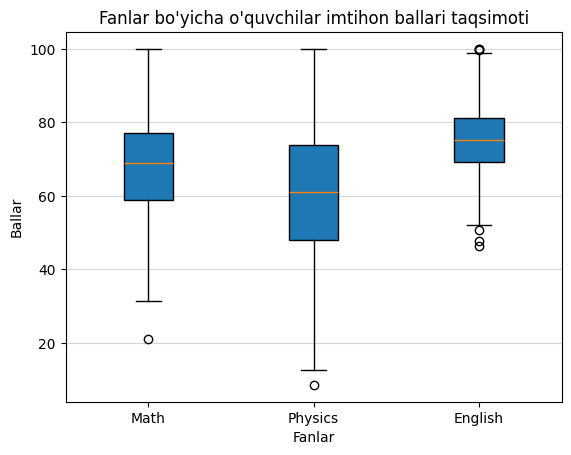

In [26]:
# grafik chizish
plt.boxplot(scores, tick_labels=subjects, patch_artist=True)

plt.title("Fanlar bo'yicha o'quvchilar imtihon ballari taqsimoti")
plt.xlabel("Fanlar")
plt.ylabel("Ballar")
plt.grid(axis='y', alpha=0.5)

plt.show()

- Maktab o'quvchilarining ko'p qismi Ingiliz tilidan yuqori natijalar qayd etishgan . Biroq Fizika fanidan esa turlicha baholar olishgan .
- Matematika fanini ham o'zlashtirishlari yaxshi ekanligi ko'rinib turibdi .
- Uchchala fanlarda ham juda past ball olgan o'quvchilar mavjud , ayniqsa Fizika fanida . O'quvchini bunday past bal olganini aniqlash lozim . Fizikadan qo'shimda darslar joriy etilishi kerak .

In [27]:
# yirik kompaniyaning 800 nafar xodimi bo'yicha, ta'lim darajasi va yillik maoshi ma'lumotlari
np.random.seed(41)

df_salary_by_edu = pd.DataFrame({
    'education_level': np.repeat(['High School', 'Bachelor', 'Master', 'PhD'], 200),
    'annual_salary': np.concatenate([
        np.random.normal(38000, 6000, 200),
        np.random.normal(52000, 9000, 200),
        np.random.normal(68000, 11000, 200),
        np.random.normal(85000, 15000, 200)
    ]).clip(20000, None).round(0)
})

df_salary_by_edu.head()

,education_level,annual_salary
0,High School,36376.0
1,High School,38629.0
2,High School,39503.0
3,High School,32449.0
4,High School,41403.0


In [28]:
# ma'lumotlarni ro'yxat qilish
levels = df_salary_by_edu['education_level'].unique()
salary = [df_salary_by_edu[df_salary_by_edu['education_level'] == level]['annual_salary'] for level in levels]

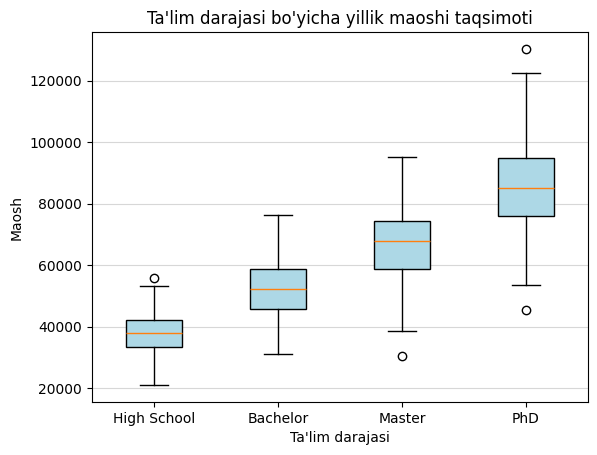

In [29]:
plt.boxplot(salary, tick_labels=levels, patch_artist=True, boxprops=dict(facecolor='lightblue'))

plt.title("Ta'lim darajasi bo'yicha yillik maoshi taqsimoti")
plt.xlabel("Ta'lim darajasi")
plt.ylabel("Maosh")
plt.grid(axis='y', alpha=0.5)

plt.show()

- Ta'lim darajasi qanchalik yuqori bo'lsa , yillik maosh ham yuqori bo'lishini ko'rishimiz mumkin .
- Eng kam yillik maoshni O'rta maxsus darajasi olsa , eng yuqori yillik maoshni PhD darjasidagi kasb egalari olishar ekan .
- O'rta maxsus , Magistr va PhD darajalarida outlierlar mavjud . Ularni nega bunday katta yoki kam yillik maosh olishini o'rganib chiqish zarur .

In [30]:
np.random.seed(63)

df_traffic_sources = pd.DataFrame({
    'traffic_source': ['Organic Search', 'Social Media', 'Direct', 'Referral', 'Email', 'Paid Ads'],
    'visits': [18400, 12600, 9800, 5200, 4100, 7300]
})

df_traffic_sources

,traffic_source,visits
0,Organic Search,18400
1,Social Media,12600
2,Direct,9800
3,Referral,5200
4,Email,4100
5,Paid Ads,7300


- yuqoridagi `df_traffic_sources` dataframeymi - onlayn magazinning veb-saytiga kirish manbalari (traffic source) bo'yicha, bir oy davomida qayd etilgan tashriflar ulushi ma'lumotlarini saqlagan

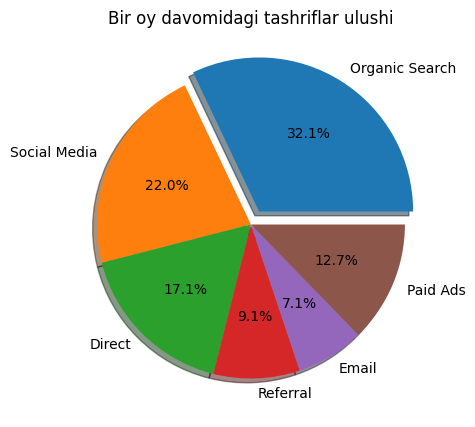

In [31]:
plt.figure(figsize=(9, 5))
plt.pie(df_traffic_sources['visits'], labels=df_traffic_sources['traffic_source'], autopct='%1.1f%%', explode=(0.1, 0, 0, 0, 0, 0), shadow=True)

plt.title("Bir oy davomidagi tashriflar ulushi")


plt.show()

- Organic Search 32.1% bilan saytga eng ko'p foydalanuvchini olib kelgan yetakchi manba hisoblanadi . Undan so'ng esa Social Media 22% bilan keyingi o'rinda turadi
- Email va Referral eng kam foydalanuvchi olib kelayotgan manbalar hisoblanadi
- Eng past natija ko'rsatgan email manbalarining strategiyasini qayta ko'rib chiqish tavsiya etiladi

In [32]:
# oilaning bir oylik xarajatlar byudjeti ma'lumotlari
np.random.seed(55)

df_expense_budget = pd.DataFrame({
    'expense_category': ['Housing', 'Food', 'Transportation', 'Utilities',
                          'Entertainment', 'Healthcare', 'Savings', 'Other'],
    'amount_usd': [1450, 620, 340, 210, 180, 150, 500, 150]
})

df_expense_budget

,expense_category,amount_usd
0,Housing,1450
1,Food,620
2,Transportation,340
3,Utilities,210
4,Entertainment,180
5,Healthcare,150
6,Savings,500
7,Other,150


In [33]:
# oylikni ko'pdan kamga tartiblash
df_expense_budget['amount_usd'] = df_expense_budget['amount_usd'].sort_values(ascending=False)

In [36]:
# 5% va undan kam bo'lgan ulushlarni Other qilish
jami_harajat = df_expense_budget['amount_usd'].sum()
df_expense_budget['ulush'] = (df_expense_budget['amount_usd']/jami_harajat)*100
df_expense_budget.loc[df_expense_budget['ulush'] <= 5, 'expense_category'] = 'Other'

df_pie = df_expense_budget.groupby('expense_category', as_index=False)['amount_usd'].sum()

In [41]:
df_pie

,expense_category,amount_usd
0,Food,620
1,Housing,1450
2,Other,480
3,Savings,500
4,Transportation,340
5,Utilities,210


In [44]:
# df_pie jadvalidagi oyliklarni ko'pdan kamga qarab taqsimlash
df_pie = df_pie.sort_values(by='amount_usd', ascending=False)
df_pie

,expense_category,amount_usd
1,Housing,1450
0,Food,620
3,Savings,500
2,Other,480
4,Transportation,340
5,Utilities,210


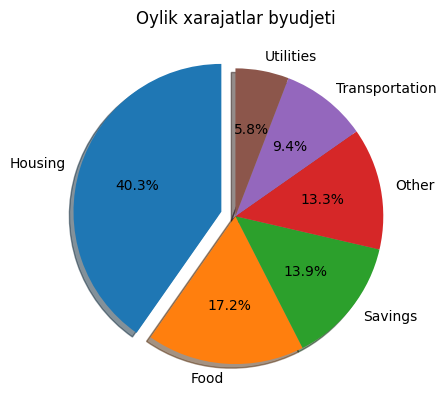

In [46]:
plt.pie(df_pie['amount_usd'], labels=df_pie['expense_category'], autopct='%1.1f%%', startangle=90, explode=[0.1, 0, 0, 0, 0, 0], shadow=True)

plt.title("Oylik xarajatlar byudjeti")

plt.show()

- Uy-joy 40.3% ko'rsatkich bilan umumiy oylik byudjetning eng katta qismini tashkil qilmoqda va qolgan toifalardan yaqqol ajralib turibdi
- Oziq-ovqat harajatlari harajatlari , budjetning 17.2% ga egalik qiladi
- Jamg'armalar byudjetning 13.9% qismini, Boshqa xarajatlar esa 13.3% qismini qamrab olgan bo'lib, ularning ko'rsatkichlari bir-biriga juda yaqin
- Eng kam ulushlarni qayd etganlar esa transport hizmatlari va kommunal to'lovlar ekanini ko'rishimiz mumkin
- Oylik maoshni tejash uchun boshqa va oziq-ovqat ehtiyojlarini kamaytirishni ko'rib chiqish kerak bo'ladi

In [47]:
# ikkita kompaniya aksiyasining (TechCorp va RetailCo) 2023 yildagi kunlik yopilish narxi ma'lumotlari
np.random.seed(72)

dates = pd.bdate_range(start='2023-01-01', end='2023-12-29')

df_stock_prices = pd.DataFrame({
    'date': dates,
    'techcorp_price': (150 + np.cumsum(np.random.normal(0.15, 2.5, len(dates)))).round(2),
    'retailco_price': (85 + np.cumsum(np.random.normal(0.02, 1.2, len(dates)))).round(2)
})

df_stock_prices.shape

(260, 3)

In [48]:
df_stock_prices.head()

,date,techcorp_price,retailco_price
0,2023-01-02,150.95,86.71
1,2023-01-03,149.40,86.34
2,2023-01-04,144.03,89.10
3,2023-01-05,145.65,88.99
4,2023-01-06,149.99,89.54
